In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import warnings
import linearmodels.panel as lmp
from numpy.linalg import matrix_rank

warnings.filterwarnings("ignore")

%matplotlib inline

In [10]:
df = pd.read_csv('panel_eps.csv')
df['edad'] = df.apply(lambda row: 2000 + row['year'] - row['edad'] if row['edad'] > 1900 else row['edad'], axis=1)
df['expectancy']=df.apply(lambda row:  np.nan if row['expectancy'] > 120 else row['expectancy'], axis=1)
df['log_wage'] = np.log(df['wage'] - df['wage'].min() + 0.1)
df['log_assets'] = np.log(df['assets'] - df['assets'].min() + 0.1)
df['assets'] = df['assets']/1000
df['wage'] = df['wage']/1000
df = df.drop(columns=['fondoa', 'fondob', 'fondoc', 'fondod', 'fondoe'])
print(df.describe())

          folio_n20          year          time          edad        hombre  \
count  9.684600e+04  96846.000000  96846.000000  96846.000000  96796.000000   
mean   1.253178e+11      7.991213      3.493898     27.003459      0.494979   
std    1.296642e+09      4.566324      1.727313     17.505680      0.499977   
min    1.245602e+11      2.000000      1.000000     19.000000      0.000000   
25%    1.246212e+11      4.000000      2.000000     20.000000      0.000000   
50%    1.247076e+11      6.000000      3.000000     20.000000      0.000000   
75%    1.248369e+11     12.000000      5.000000     20.000000      1.000000   
max    1.281337e+11     15.000000      6.000000    111.000000      1.000000   

                edu        region       status          kids      children  \
count  92920.000000  80848.000000  96736.00000  96846.000000  78017.000000   
mean       7.905585      9.148959      2.62378      0.357082      0.741633   
std        5.106440      3.678007      1.73293      0.

In [11]:
df['status'] = df['status'].replace({1: "casado", 2:"convive", 3:"divorciado", 4:"viudo", 5:"soltero"})
df['situation'] = df['situation'].replace({1: "otro", 2:"cesante", 3:"trabajando", 4:"inactivo"})
df['lmp'] = df['lmp'].replace({1: "part-time worker", 2: "full-time worker", 3:"not working"})
df = pd.get_dummies(df, columns=['status', 'situation', 'lmp', "region", 'occupation'], prefix=['status', 'situation', 'lmp', "region", 'occupation'], dtype=int, drop_first=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96846 entries, 0 to 96845
Data columns (total 58 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   folio_n20             96846 non-null  int64  
 1   year                  96846 non-null  int64  
 2   time                  96846 non-null  int64  
 3   edad                  96846 non-null  float64
 4   hombre                96796 non-null  float64
 5   edu                   92920 non-null  float64
 6   kids                  96846 non-null  int64  
 7   children              78017 non-null  float64
 8   exp                   84869 non-null  float64
 9   size                  29044 non-null  float64
 10  wage                  53897 non-null  float64
 11  hours                 54576 non-null  float64
 12  informal              41259 non-null  float64
 13  selfemp               55502 non-null  float64
 14  publicemp             55502 non-null  float64
 15  sistema            

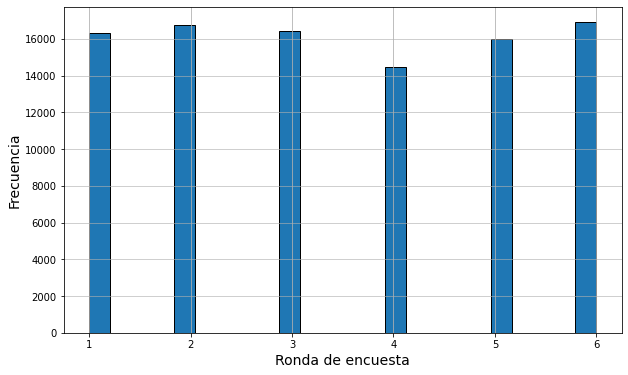

In [12]:
df['time'].hist(bins=24, edgecolor='black', figsize=(10, 6))

plt.xlabel('Ronda de encuesta', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.grid(axis='y', alpha=0.75) 
plt.show()

Existe atrición pero muy poca.

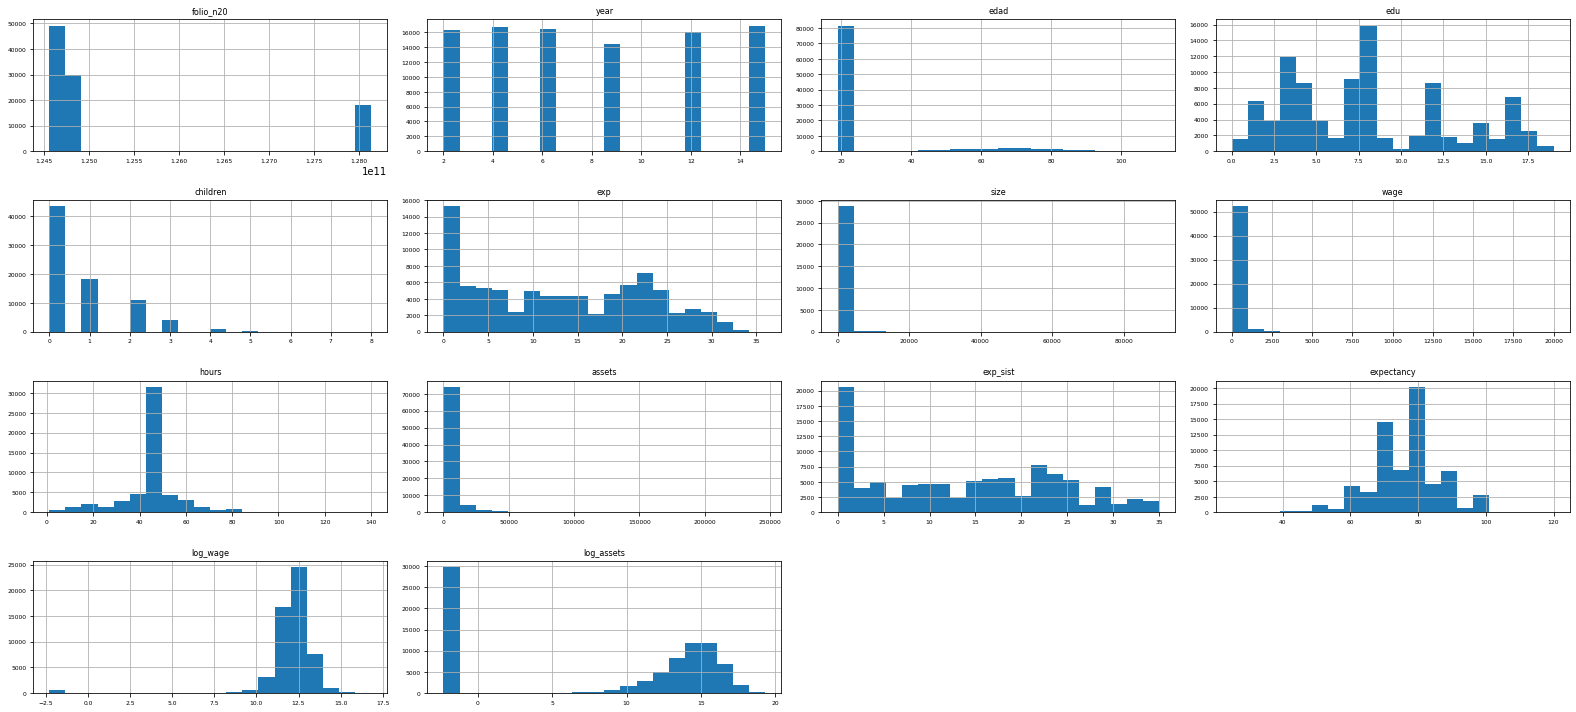

In [13]:

# Seleccionar columnas no binarias (más de 2 valores únicos)
non_binary_cols = [col for col in df.columns if df[col].nunique() > 2 and col != 'time']
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(22, 10))
axes = axes.flatten()

# Graficar histogramas
for i, col in enumerate(non_binary_cols):
    df[col].hist(ax=axes[i], bins=20)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(axis='x', labelsize=6)
    axes[i].tick_params(axis='y', labelsize=6)

# Ocultar los subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [14]:
df_original = df.copy()

num_cols = ['size', 'wage', 'assets', 'hours']

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[num_cols] < (Q1 - 5 * IQR)) | 
                (df[num_cols] > (Q3 + 5 * IQR)))

outliers_per_column = outlier_mask.sum()

df = df[~outlier_mask.any(axis=1)]

print(outliers_per_column[outliers_per_column > 0])



size      1063
wage       735
assets    3386
hours     6608
dtype: int64


Se eliminan outliers con un marco muy conservador de 5IQR.

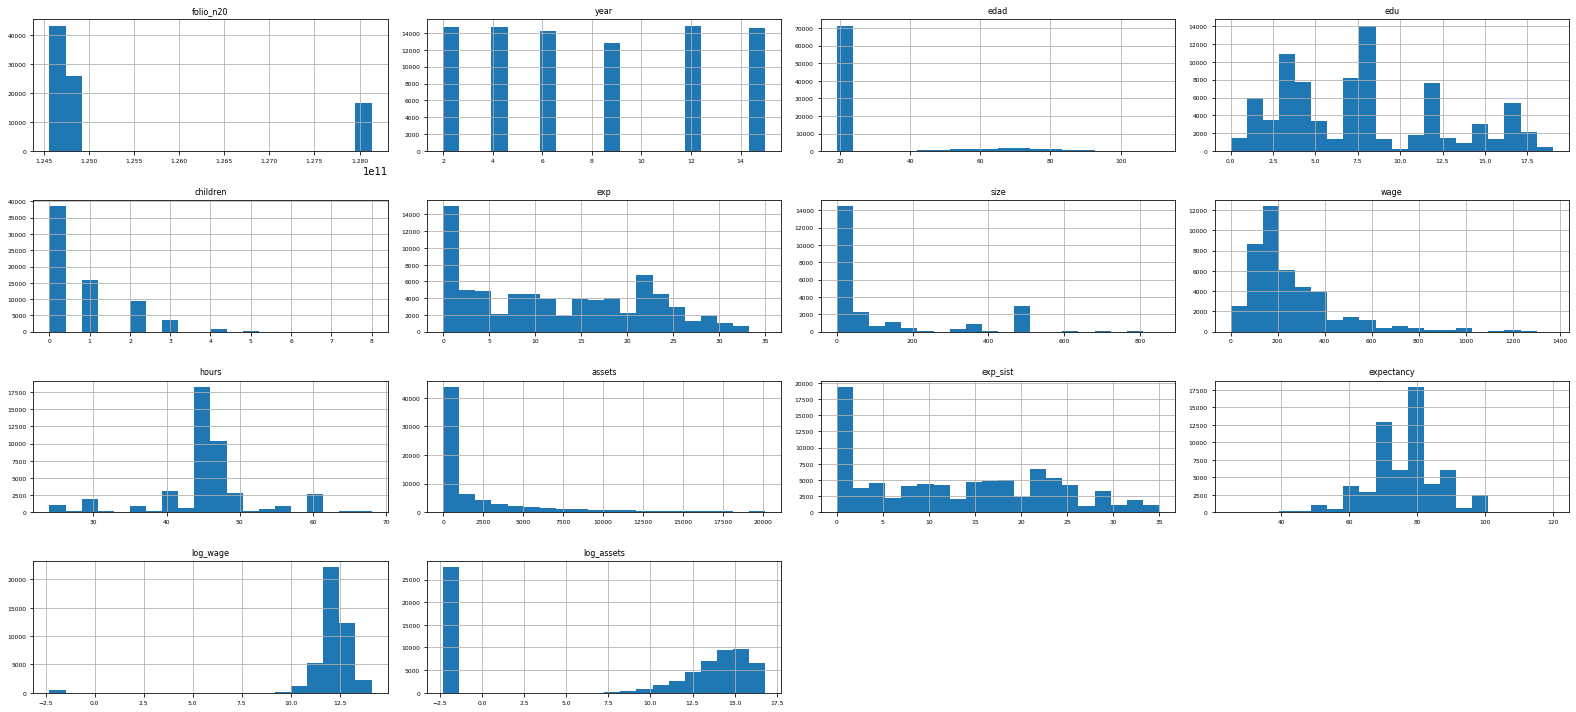

In [15]:

non_binary_cols = [col for col in df.columns if df[col].nunique() > 2 and col != 'time']
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(non_binary_cols):
    df[col].hist(ax=axes[i], bins=20)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(axis='x', labelsize=6)
    axes[i].tick_params(axis='y', labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [16]:
df['ronda'] = df['time']
df = pd.get_dummies(df, columns=['time'], prefix=['time'], dtype=int)

2. 

In [17]:
# Calcular correlaciones con 'expectancy'
correlations = df.corr(numeric_only=True)['expectancy'].drop('expectancy')

# Filtrar solo correlaciones fuertes (mayores a 0.3 o menores a -0.3)
filtered_correlations = correlations[(correlations > 0.03) | (correlations < -0.03)]

filtered_correlations = filtered_correlations.sort_values(ascending=False).to_frame(name='Correlation with expectancy')

print(filtered_correlations)



                      Correlation with expectancy
edad                                     0.188057
status_viudo                             0.120429
wage                                     0.094256
ronda                                    0.092476
year                                     0.091418
situation_inactivo                       0.091271
time_5                                   0.065986
hombre                                   0.058202
log_wage                                 0.046474
time_4                                   0.030525
region_8.0                              -0.031356
status_convive                          -0.033691
occupation_9.0                          -0.038043
region_2.0                              -0.038635
occupation_5.0                          -0.041485
status_divorciado                       -0.041571
informal                                -0.044034
exp_sist                                -0.044566
situation_trabajando                    -0.048776


In [18]:
from linearmodels.panel import PooledOLS

variables = ['edu', 'edad', 'status_viudo', 'log_wage', 'situation_inactivo', 'hombre','illness', 'kids', 'sistema', 'region_8.0', 'status_convive', 'occupation_9.0', 'region_2.0', 'occupation_5.0', 'status_divorciado', 'exp_sist']
df_model = df[variables + ['expectancy', 'folio_n20', 'ronda']]


df_model = df_model.set_index(['folio_n20', 'ronda'])

y = df_model['expectancy']
X = df_model.drop(columns=['expectancy'])
X = sm.add_constant(X)  
pooled_model = PooledOLS(y, X)
pooled_model = pooled_model.fit()

print(pooled_model)


                          PooledOLS Estimation Summary                          
Dep. Variable:             expectancy   R-squared:                        0.0230
Estimator:                  PooledOLS   R-squared (Between):              0.0261
No. Observations:               20960   R-squared (Within):               0.0164
Date:                Wed, May 21 2025   R-squared (Overall):              0.0230
Time:                        06:37:52   Log-likelihood                -7.782e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      30.844
Entities:                       12021   P-value                           0.0000
Avg Obs:                       1.7436   Distribution:                F(16,20943)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             30.844
                            

El modelo Pooled OLS muestra que la educación tiene un efecto positivo y significativo sobre la expectativa de vida: cada año adicional de educación aumenta en 0.09 años la expectativa autorreportada. También tienen efectos positivos la edad, el ingreso logarítmico, el sexo masculino y la experiencia en el sistema previsional. En cambio, tener enfermedades o hijos se asocia con una menor expectativa de vida. El modelo explica un 2.3% de la variación total, lo que indica una capacidad explicativa baja, aunque el P-value indica significancia.

3. 

In [19]:
model=lmp.PanelOLS(y,X, entity_effects=True, drop_absorbed=True)
fe=model.fit(cov_type='robust')
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0288
Estimator:                   PanelOLS   R-squared (Between):             -0.1624
No. Observations:               20960   R-squared (Within):               0.0288
Date:                Wed, May 21 2025   R-squared (Overall):             -0.0970
Time:                        06:37:53   Log-likelihood                 -6.56e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      17.655
Entities:                       12021   P-value                           0.0000
Avg Obs:                       1.7436   Distribution:                 F(15,8924)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):          6.005e+16
                            

El modelo de efectos fijos muestra que educación no tiene un efecto significativo sobre la expectativa de vida (coef. = -0.0069, p = 0.87), lo cual es esperable si no varía en el tiempo. En cambio, edad (coef. = 0.57, p < 0.01) y experiencia en el sistema previsional (coef. = 0.4, p < 0.001) sí tienen efectos positivos y significativos. Tener enfermedades reduce la expectativa de vida de forma importante (coef. = -1.1, p < 0.001). Variables como sexo, región, estado civil y ocupación no resultaron significativas. El R^2 se mantiene relativamente igual a la estimación Pooled.

4.

In [20]:
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3502
Estimator:              RandomEffects   R-squared (Between):              0.0261
No. Observations:               20960   R-squared (Within):               0.0176
Date:                Wed, May 21 2025   R-squared (Overall):              0.0228
Time:                        06:37:54   Log-likelihood                -7.458e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      705.36
Entities:                       12021   P-value                           0.0000
Avg Obs:                       1.7436   Distribution:                F(16,20943)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             30.401
                            

expectativa de vida (coef. = 0.11, p < 0.001): por cada año adicional de educación, la expectativa autorreportada aumenta en aproximadamente 0.11 años. También tienen efectos positivos la edad y la experiencia en el sistema previsional, mientras que tener enfermedades y tener hijos se asocian negativamente con la expectativa de vida.

Además, se observan diferencias sistemáticas por sexo (ser hombre aumenta la expectativa), región y ocupación, lo que sugiere la presencia de factores estructurales que influyen en la percepción de longevidad.

El modelo logra un R^2 total de 38.9%, lo que indica un poder explicativo considerable, y todas las variables incluidas resultan significativas. Este resultado sugiere que el modelo RE es capaz de capturar tanto la variación entre individuos como la variación temporal relevante en el panel.

5. 

En el modelo Pooled OLS (pregunta 2), se encontró un efecto positivo y significativo de la educación sobre la expectativa de vida (coef. ≈ 0.09, p < 0.001), junto con otros efectos significativos como edad, ingreso y experiencia previsional. Sin embargo, este modelo no controla por heterogeneidad no observada entre individuos, lo que puede generar sesgo por omisión de variables constantes.

El modelo de efectos fijos (pregunta 3) controla por estas características individuales invariables, pero elimina del análisis cualquier variable constante en el tiempo, como la educación si no varía dentro del individuo. Como resultado, el coeficiente de educación no fue significativo (coef. ≈ -0.01, p = 0.81), lo que sugiere que su efecto no puede identificarse usando solo variación temporal dentro de los individuos.

Por otro lado, el modelo de efectos aleatorios (pregunta 4) permite estimar el efecto de variables constantes, bajo el supuesto de que los efectos individuales no están correlacionados con los regresores. En este caso, el efecto de la educación volvió a ser positivo y significativo (coef. ≈ 0.11, p < 0.001), con un R² total del 38.9%, mucho más alto que en los modelos anteriores.

In [21]:
print(lmp.compare({"FE": fe, "RE": re, "Pooled": pooled_model}))

                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects      PooledOLS
No. Observations                 20960             20960          20960
Cov. Est.                       Robust            Robust     Unadjusted
R-squared                       0.0288            0.3502         0.0230
R-Squared (Within)              0.0288            0.0176         0.0164
R-Squared (Between)            -0.1624            0.0261         0.0261
R-Squared (Overall)            -0.0970            0.0228         0.0230
F-statistic                     17.655            705.36         30.844
P-value (F-stat)                0.0000            0.0000         0.0000
=====================     ============   ===============   =====

In [22]:
import numpy.linalg as la
from scipy import stats
def hausman(fe, re):
    diff = fe.params-re.params
    psi = fe.cov - re.cov
    dof = diff.size -1
    W = diff.dot(la.inv(psi)).dot(diff)
    pval = stats.chi2.sf(W, dof)
    return W, dof, pval
htest = hausman(fe, re)
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0],htest[1], htest[2]))

Hausman Test: chi-2 = nan, df = 16, p-value = nan


6.

In [23]:
Xm = df.drop('expectancy', axis=1).groupby('folio_n20').transform('mean').drop('ronda', axis=1)
Xm.columns = ['m{}'.format(col) for col in Xm.columns]

Xc = pd.concat([df, Xm], axis=1)
Xc = Xc.set_index(['folio_n20', 'ronda'])

y = Xc['expectancy']


vars_originales = ['edu', 'edad', 'situation_inactivo', 'hombre',
                   'illness', 'kids', 'sistema', 'region_8.0', 'status_convive',
                   'occupation_9.0', 'region_2.0', 'occupation_5.0',
                   'status_divorciado', 'exp_sist']
vars_medias = ['m' + v for v in vars_originales]
X = Xc[vars_originales + vars_medias ]

# Eliminar colinealidad: quitar duplicadas o constantes
X = X.loc[:, X.apply(lambda col: col.nunique() > 1)]
X = X.loc[:, ~X.T.duplicated()]
X = sm.add_constant(X)  


from linearmodels.panel import RandomEffects
model = RandomEffects(y, X)
cre = model.fit(cov_type="robust")
print(cre)



                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3917
Estimator:              RandomEffects   R-squared (Between):              0.0785
No. Observations:               33365   R-squared (Within):               0.0275
Date:                Wed, May 21 2025   R-squared (Overall):              0.0625
Time:                        06:38:06   Log-likelihood                -1.186e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      795.01
Entities:                       18118   P-value                           0.0000
Avg Obs:                       1.8415   Distribution:                F(27,33337)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             86.373
                            

El modelo de efectos aleatorios correlacionados (CRE) muestra que la educación no tiene un efecto significativo dentro del individuo, pero sí lo tiene entre individuos: la media de educación (medu) es positiva y significativa, indicando que personas con mayor nivel educativo tienden a reportar una mayor expectativa de vida.

También resultaron significativos:

Edad (positivo dentro del individuo),

Experiencia en el sistema previsional (positiva dentro, negativa entre),

Presencia de enfermedades (negativa en ambos niveles),

Sexo masculino (positivo),

Y algunas variables medias de contexto como msituation_inactivo y mkids.

El modelo logra un R² total de 39.2%, lo que refleja un buen ajuste. En conjunto, el CRE es adecuado para esta base de datos, ya que permite estimar efectos de variables constantes controlando por heterogeneidad no observada, combinando ventajas de los modelos de efectos fijos y aleatorios.